# Análisis Exploratorio de Datos (EDA) y Preprocesamiento

## Carga del datatset desde S3

In [20]:
# Verificamos la existencia del bucket y que lo podemos leer correctamente

import boto3

s3 = boto3.client('s3')

for bucket in s3.list_buckets()['Buckets']:
    print(bucket['Name'])

sisfall-fall-detection


In [21]:
# Revisión archivos .csv existentes en la carpeta /processed

response = s3.list_objects_v2(
    Bucket='sisfall-fall-detection',
    Prefix='processed/'
)

for obj in response.get('Contents', []):
    print(obj['Key'])

processed/
processed/D01_SA01_R01.csv
processed/D02_SA01_R01.csv
processed/D07_SE14_R01.csv
processed/D17_SE13_R01.csv
processed/F01_SA17_R01.csv
processed/F07_SA18_R01.csv
processed/F09_SA19_R05.csv
processed/F15_SA06_R05.csv
processed/F15_SA23_R04.csv


In [22]:
# Cargar y unir archivos .csv desde S3 (solo con label)

import pandas as pd
import boto3

s3 = boto3.client('s3')

bucket = 'sisfall-fall-detection'

response = s3.list_objects_v2(
    Bucket=bucket,
    Prefix='processed/'
)

files = [obj['Key'] for obj in response['Contents'] if obj['Key'].endswith('.csv')]

dfs = []

for file in files:
    obj = s3.get_object(Bucket=bucket, Key=file)
    df = pd.read_csv(obj['Body'])
    
    # solo usar datos con label (training)
    if 'label' in df.columns:
        dfs.append(df)

dataset = pd.concat(dfs, ignore_index=True)

print("Shape dataset:", dataset.shape)
print(dataset['label'].value_counts())

Shape dataset: (62397, 11)
label
0    47398
1    14999
Name: count, dtype: int64


## Equilibrio del dataset

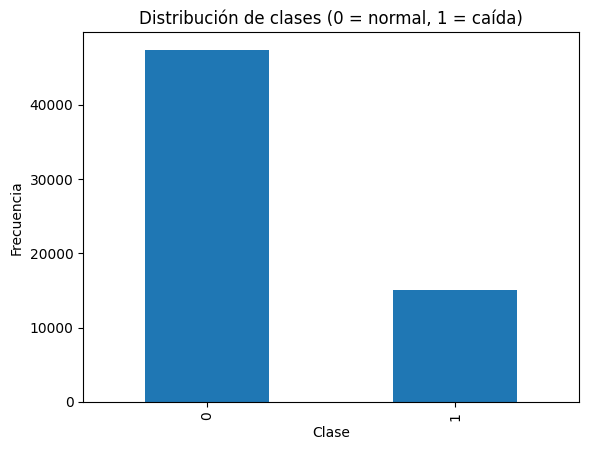

In [23]:
# Distribución de clases

import matplotlib.pyplot as plt

dataset['label'].value_counts().plot(kind='bar')
plt.title("Distribución de clases (0 = normal, 1 = caída)")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.show()

## Análisis de distribución de variables

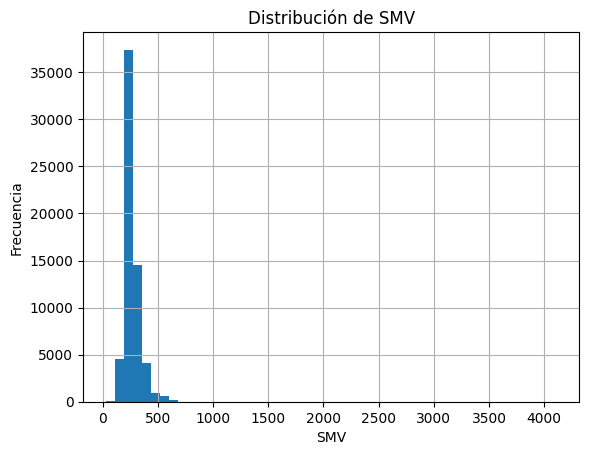

In [24]:
# Distribución de SMV

dataset['smv'].hist(bins=50)
plt.title("Distribución de SMV")
plt.xlabel("SMV")
plt.ylabel("Frecuencia")
plt.show()

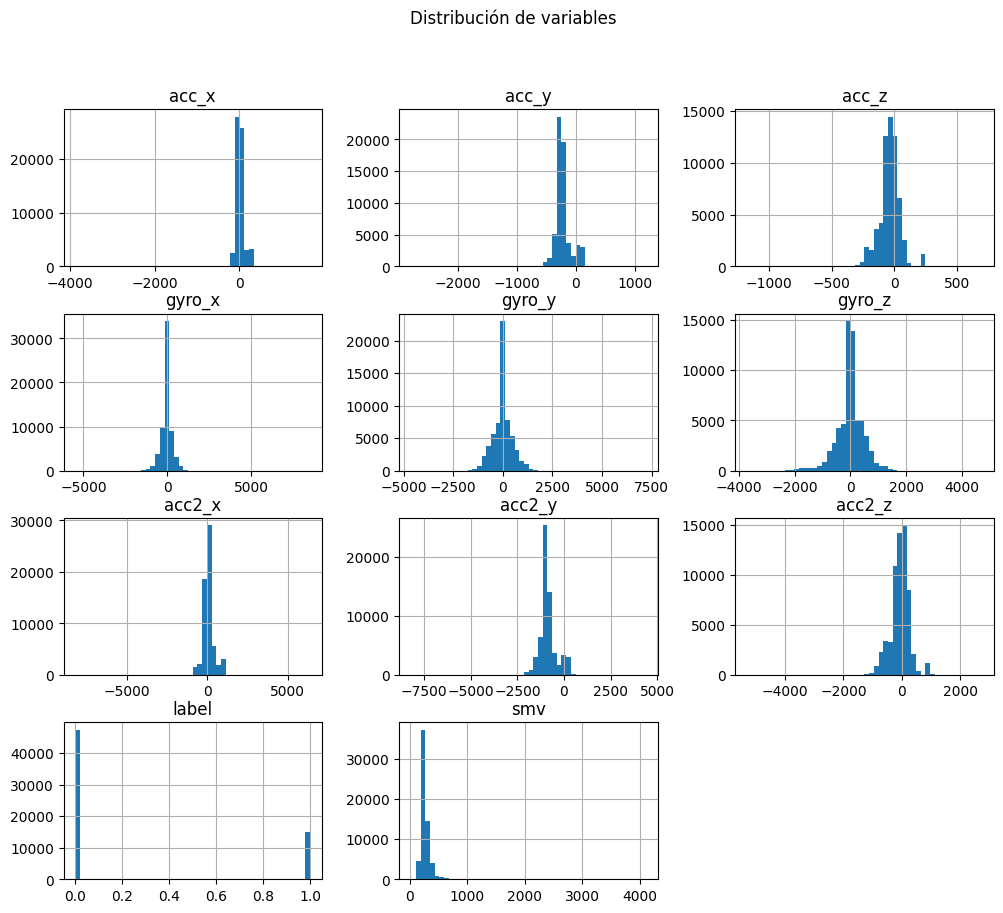

In [25]:
# Distribución de variables

import matplotlib.pyplot as plt

dataset.hist(figsize=(12,10), bins=50)
plt.suptitle("Distribución de variables")
plt.show()

In [26]:
# Correlación con la variable target

corr = dataset.corr()

corr_target = corr["label"].sort_values(ascending=False)

print(corr_target)

label     1.000000
acc_y     0.577161
acc2_y    0.576872
acc_x     0.290912
acc2_x    0.277019
gyro_y    0.055801
gyro_x    0.022519
acc_z    -0.008303
gyro_z   -0.021643
smv      -0.049185
acc2_z   -0.121427
Name: label, dtype: float64


In [27]:
# Validación de estructura del dataset

dataset.head(10)

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,acc2_x,acc2_y,acc2_z,label,smv
0,17,-179,-99,-18,-504,-352,76,-697,-279,0,205.258374
1,15,-174,-90,-53,-568,-306,48,-675,-254,0,196.471372
2,1,-176,-81,-84,-613,-271,-2,-668,-221,0,193.747258
3,-10,-180,-77,-104,-647,-227,-34,-697,-175,0,196.033160
4,-21,-191,-63,-128,-675,-191,-74,-741,-133,0,202.215232
5,-37,-225,-59,-146,-700,-159,-110,-840,-103,0,235.531314
6,-36,-243,-46,-166,-722,-131,-147,-948,-75,0,249.921988
7,-44,-271,-38,-190,-738,-107,-171,-1073,-38,0,277.166015
8,-51,-312,-33,-210,-752,-90,-200,-1191,3,0,317.858459
9,-55,-339,-19,-214,-764,-72,-212,-1298,52,0,343.957846


# División de los datos

In [28]:
# Preparar datos (train/test)

from sklearn.model_selection import train_test_split

X = dataset.drop("label", axis=1)
y = dataset["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (49917, 10)
Test: (12480, 10)


# (Random Forest) Entrenamiento del modelo y realización de las predicciones

## (Random Forest) Entrenamiento modelo

In [29]:
# Entrenar modelo (Random Forest)

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## (Random Forest) Evaluar métricas

In [30]:
# Evaluar modelo (métricas)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.9614583333333333
Precision: 0.999618320610687
Recall: 0.8451113262342691
F1-score: 0.9158943871306172


# (Random Forest) Validación del modelo

In [31]:
## Pruebas Cuantitativas

In [32]:
# Validación cualitativa

import pandas as pd
import numpy as np

# Obtenemos las predicciones del modelo inicial para localizar los fallos
y_pred_inicial = model.predict(X_test)

# Localizamos los índices exactos de esos 4 ejemplos en el set de test
# Usamos [0] para encontrar el primero que encuentre de cada tipo
idx_tp = np.where((y_test == 1) & (y_pred_inicial == 1))[0][0]
idx_tn = np.where((y_test == 0) & (y_pred_inicial == 0))[0][0]
idx_fn = np.where((y_test == 1) & (y_pred_inicial == 0))[0][0]
idx_fp = np.where((y_test == 0) & (y_pred_inicial == 1))[0][0]

indices = [idx_tp, idx_tn, idx_fn, idx_fp]
titulos = ["CASO 1: ACIERTO CAÍDA", "CASO 2: ACIERTO NORMAL", "CASO 3: FALLO (Falso Negativo)", "CASO 4: FALLO (Falso Positivo)"]

print("=== EXTRACCIÓN DE DATOS REALES ===\n")

for i, idx in enumerate(indices):
    # Pillamos la fila con los 10 sensores reales
    datos_reales = X_test.iloc[[idx]]
    
    # Predicción del modelo inicial
    pred_ini = model.predict(datos_reales)[0]
    conf_ini = model.predict_proba(datos_reales)[0][pred_ini] * 100
    
    print(f"{titulos[i]} (Índice: {idx})")
    print(f"DATOS: {datos_reales.to_dict(orient='records')[0]}")
    print(f"Resultado Inicial: {pred_ini} ({conf_ini:.2f}% conf)")
    print("-" * 50)

=== EXTRACCIÓN DE DATOS REALES ===

CASO 1: ACIERTO CAÍDA (Índice: 3)
DATOS: {'acc_x': 203, 'acc_y': 23, 'acc_z': -145, 'gyro_x': 79, 'gyro_y': 44, 'gyro_z': 16, 'acc2_x': 824, 'acc2_y': 82, 'acc2_z': -578, 'smv': 250.5254478091996}
Resultado Inicial: 1 (100.00% conf)
--------------------------------------------------
CASO 2: ACIERTO NORMAL (Índice: 0)
DATOS: {'acc_x': -3, 'acc_y': -231, 'acc_z': -36, 'gyro_x': 9, 'gyro_y': -596, 'gyro_z': -173, 'acc2_x': -4, 'acc2_y': -900, 'acc2_z': -3, 'smv': 233.8076132207846}
Resultado Inicial: 0 (93.07% conf)
--------------------------------------------------
CASO 3: FALLO (Falso Negativo) (Índice: 55)
DATOS: {'acc_x': -15, 'acc_y': -267, 'acc_z': -118, 'gyro_x': 121, 'gyro_y': -587, 'gyro_z': -82, 'acc2_x': -37, 'acc2_y': -1025, 'acc2_z': -539, 'smv': 292.297793354654}
Resultado Inicial: 0 (66.05% conf)
--------------------------------------------------
CASO 4: FALLO (Falso Positivo) (Índice: 2406)
DATOS: {'acc_x': -26, 'acc_y': -250, 'acc_z': -

## (Random Forest) Matriz de confusion

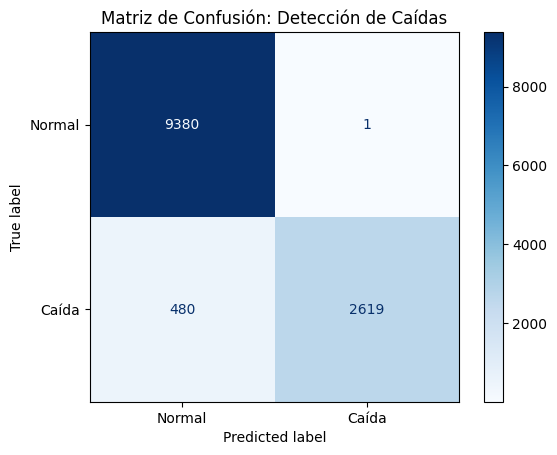

In [33]:
# Matriz de confusión

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Usamos la función oficial de sklearn que dibuja la matriz automáticamente
# Solo necesita tu 'model', los datos de test y las etiquetas
disp = ConfusionMatrixDisplay.from_estimator(
    model, 
    X_test, 
    y_test, 
    display_labels=['Normal', 'Caída'],
    cmap=plt.cm.Blues, # Color azul profesional
    values_format='d'   # Para que salgan números enteros y no decimales
)

# Personalizamos el título
plt.title('Matriz de Confusión: Detección de Caídas')

# Quitamos las líneas de cuadrícula del fondo para que se vea limpia
plt.grid(False)

# Mostramos la imagen
plt.show()

## (Random Forest) Curva de precisión - Recall

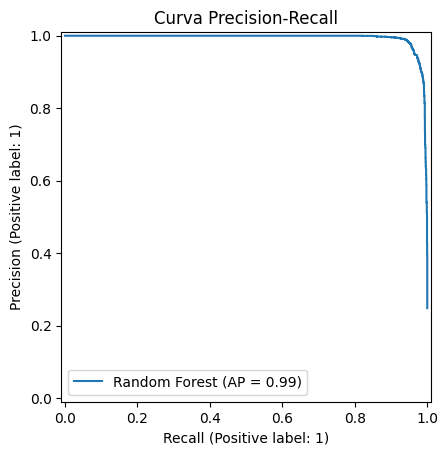

In [34]:
# Curva de precisión - Recall

from sklearn.metrics import PrecisionRecallDisplay

disp = PrecisionRecallDisplay.from_estimator(model, X_test, y_test, name="Random Forest")
plt.title('Curva Precision-Recall')
plt.show()

## (Random Forest) Probabilidades de caida

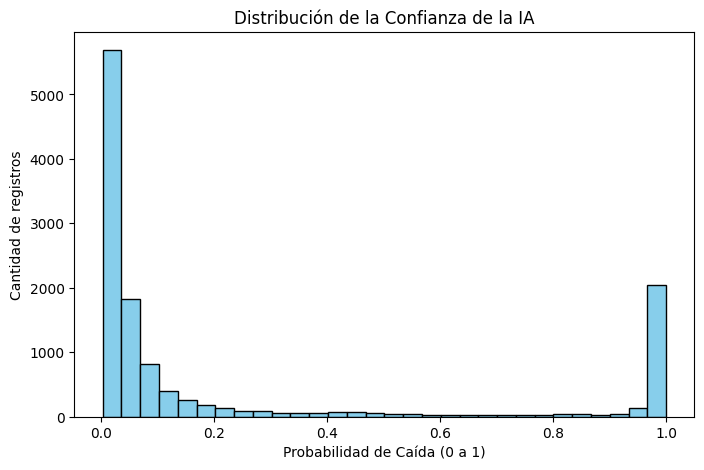

In [35]:
# Obtenemos las probabilidades de la clase 'Caída'

probs_caida = model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 5))
plt.hist(probs_caida, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de la Confianza de la IA')
plt.xlabel('Probabilidad de Caída (0 a 1)')
plt.ylabel('Cantidad de registros')
plt.show()

## (Random Forest) Intensidad de caidas (SMV)

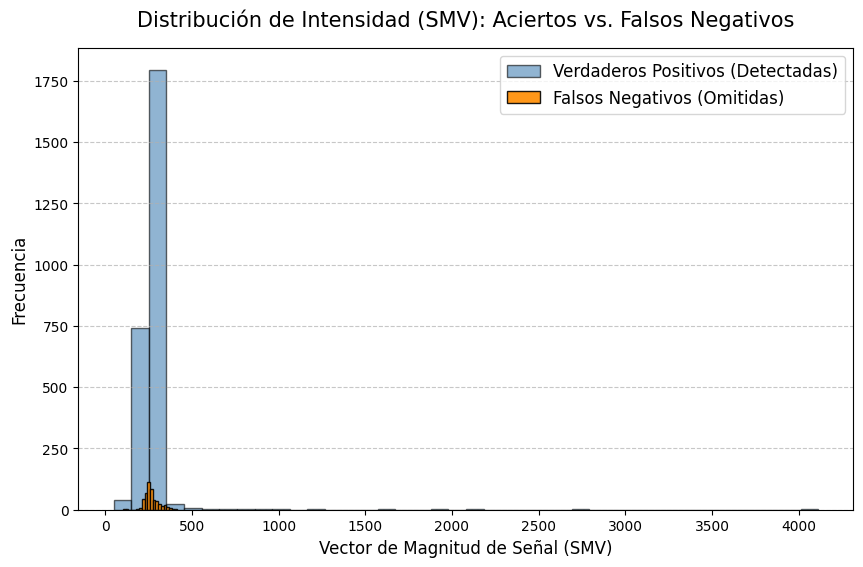

In [37]:
# Histograma de Intensidad de Caídas (SMV)

import matplotlib.pyplot as plt
import numpy as np

# Filtramos SOLO los casos que en la realidad eran CAÍDAS (y_test == 1)
caidas_reales = X_test[y_test == 1]
predicciones_caidas_reales = model.predict(caidas_reales)

# Separamos el SMV de las que detectamos bien y de las que fallamos
smv_aciertos = caidas_reales[predicciones_caidas_reales == 1]['smv'] # Verdaderos Positivos
smv_fallos = caidas_reales[predicciones_caidas_reales == 0]['smv']   # Falsos Negativos

# Dibujamos el gráfico
plt.figure(figsize=(10, 6))

# Histograma de aciertos (Azul)
plt.hist(smv_aciertos, bins=40, alpha=0.6, label='Verdaderos Positivos (Detectadas)', color='steelblue', edgecolor='black')

# Histograma de fallos (Naranja)
plt.hist(smv_fallos, bins=20, alpha=0.9, label='Falsos Negativos (Omitidas)', color='darkorange', edgecolor='black')

# Personalización formal
plt.title('Distribución de Intensidad (SMV): Aciertos vs. Falsos Negativos', fontsize=15, pad=15)
plt.xlabel('Vector de Magnitud de Señal (SMV)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# (Random Forest) Optimitzación del modelo

## (Random Forest) Buscar mejores hiperparametros para Random Forest con GridSearch (se mantiene comentada para no cargar en tiempo de computación)

In [38]:
# Buscar mejores hiperparámetros con GridSearch
'''
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Definimos la rejilla (Grid) de parámetros a explorar
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced'] # Mantenemos el balanceo para ayudar al Recall
}

# Configuramos GridSearchCV
# scoring='recall' es lo más importante: le decimos que gane el que menos caídas olvide
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='recall', 
    cv=3,       # Validación cruzada en 3 carpetas
    n_jobs=-1,  # Usa todos los procesadores de SageMaker para ir más rápido
    verbose=1   # Para ver el progreso
)

print("=== EJECUTANDO GRID SEARCH (Optimización de Hiperparámetros) ===")
grid_search.fit(X_train, y_train)

# Extraemos los resultados
modelo_grid = grid_search.best_estimator_
print(f"\ Mejores parámetros encontrados: {grid_search.best_params_}")

# Evaluación final
y_pred_grid = modelo_grid.predict(X_test)
print("\nMatriz de Confusión tras Grid Search:")
print(confusion_matrix(y_test, y_pred_grid))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_grid))
'''

<>:31: SyntaxWarning: invalid escape sequence '\ '
<>:31: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_7602/1167544037.py:31: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ Mejores parámetros encontrados: {grid_search.best_params_}")


'\nfrom sklearn.model_selection import GridSearchCV\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import confusion_matrix, classification_report\n\n# Definimos la rejilla (Grid) de parámetros a explorar\nparam_grid = {\n    \'n_estimators\': [100, 200, 300],\n    \'max_depth\': [10, 20, None],\n    \'min_samples_split\': [2, 5, 10],\n    \'class_weight\': [\'balanced\'] # Mantenemos el balanceo para ayudar al Recall\n}\n\n# Configuramos GridSearchCV\n# scoring=\'recall\' es lo más importante: le decimos que gane el que menos caídas olvide\ngrid_search = GridSearchCV(\n    estimator=RandomForestClassifier(random_state=42),\n    param_grid=param_grid,\n    scoring=\'recall\', \n    cv=3,       # Validación cruzada en 3 carpetas\n    n_jobs=-1,  # Usa todos los procesadores de SageMaker para ir más rápido\n    verbose=1   # Para ver el progreso\n)\n\nprint("=== EJECUTANDO GRID SEARCH (Optimización de Hiperparámetros) ===")\ngrid_search.fit(X_train, y_train)\n\

## (Random Forest) Entrenamiento con modelo optimizado. Metricas y Matriz de confusión

Entrenando el modelo definitivo...

MÉTRICAS MEJOR MODELO RANDOM FOREST
Accuracy (Exactitud global): 99.49%
Precision (Calidad alarmas): 99.38%
Recall (Caídas detectadas):  98.55%
F1-Score (Equilibrio):       98.96%
Average Precision (AP):      99.94%

 Artefacto guardado exitosamente como 'modelo_sisfall_optimizado.pkl'


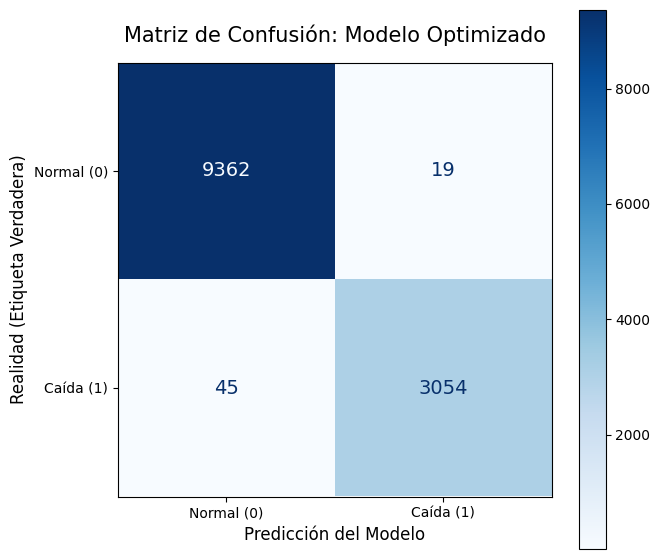

In [39]:
# Mejor modelo Random Forest con mejores metricas de GridSearch: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}

import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Instanciamos el modelo definitivo con los hiperparámetros mejores proporcionados por Gridsearch
mejor_modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

# Entrenamos el modelo con los datos
print("Entrenando el modelo definitivo...")
mejor_modelo_rf.fit(X_train, y_train)

# Realizamos las predicciones y calculamos probabilidades
y_pred_final = mejor_modelo_rf.predict(X_test)
y_probs_final = mejor_modelo_rf.predict_proba(X_test)[:, 1]

# Cálculo e impresión de métricas para el informe
print("\n" + "="*50)
print("MÉTRICAS MEJOR MODELO RANDOM FOREST")
print("="*50)
print(f"Accuracy (Exactitud global): {accuracy_score(y_test, y_pred_final)*100:.2f}%")
print(f"Precision (Calidad alarmas): {precision_score(y_test, y_pred_final)*100:.2f}%")
print(f"Recall (Caídas detectadas):  {recall_score(y_test, y_pred_final)*100:.2f}%")
print(f"F1-Score (Equilibrio):       {f1_score(y_test, y_pred_final)*100:.2f}%")
print(f"Average Precision (AP):      {average_precision_score(y_test, y_probs_final)*100:.2f}%")
print("="*50)

# Guardamos el artefacto para producción
nombre_archivo = 'modelo_sisfall_optimizado.pkl'
joblib.dump(mejor_modelo_rf, nombre_archivo)
print(f"\n Artefacto guardado exitosamente como '{nombre_archivo}'")

# Dibujamos la Matriz de Confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_final),
    display_labels=['Normal (0)', 'Caída (1)']
)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(cmap='Blues', ax=ax, values_format='d', text_kw={'fontsize': 14})

# Personalización de títulos y etiquetas
plt.title('Matriz de Confusión: Modelo Optimizado', fontsize=15, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad (Etiqueta Verdadera)', fontsize=12)
plt.show()

## (Random Forest) Pruebas cualitativas con modelo optimizado

In [40]:
# Los mismos 4 casos que probamos en la prueba cualitativa con el modelo inicial, vamos a evaluarlos con el modelo optimizado

import pandas as pd

# Aseguramos el orden de las 10 columnas del modelo
columnas = X_train.columns.tolist()

# Datos registro los mismos registros de test que se han evaluado con el modelo inicial
# Formato: [acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z, smv, acc2_x, acc2_y, acc2_z]
datos_casos = [
    # CASO 1: ACIERTO CAÍDA
    [199.00, 50.00, -155.00, 51.00, 14.00, -4.00, 257.04, -378.00, 32.00, 976.00],
    # CASO 2: ACIERTO NORMAL
    [-17.00, -243.00, -114.00, 111.00, -573.00, -121.00, 269.17, 14.00, -1014.00, -432.00],
    # CASO 3: ANTES FALLO Falso Negativo 
    [-15.00, -267.00, -118.00, 121.00, -587.00, -82.00, 292.30, 35.00, -1025.00, -428.00],
    # CASO 4: ANTES FALLO Falso Positivo
    [-26.00, -250.00, -31.00, -134.00, -195.00, 29.00, 253.25, 6.00, -1026.00, -110.00]
]

titulos = [
    "CASO 1: CAÍDA DETECTADA (Anterior Acierto)",
    "CASO 2: ACTIVIDAD NORMAL (Anterior Acierto)",
    "CASO 3: CAÍDA NO DETECTADA (Anterior Falso Negativo)",
    "CASO 4: ALARMA FALSA (Anterior Falso Positivo)"
]

esperados = [1, 0, 1, 0]

print("=== EVALUACIÓN DEL MODELO OPTIMIZADO ===\n")

for i in range(len(datos_casos)):
    # Creamos el DataFrame con la estructura que el modelo conoce
    X_input = pd.DataFrame([datos_casos[i]], columns=columnas)
    
    # Predicción con el mejor modelo del GridSearch
    pred = mejor_modelo_rf.predict(X_input)[0]
    prob = mejor_modelo_rf.predict_proba(X_input)[0][pred] * 100
    
    print(f"--- {titulos[i]} ---")
    print(f"Output Esperado: {esperados[i]} | Output Real: {pred} ({prob:.2f}% confianza)")
    
    # Verificamos si la optimización ha corregido el error
    if pred == esperados[i]:
        status = "CORRECTO"
        if i >= 2: status += " (¡ERROR CORREGIDO!)"
    else:
        status = "INCORRECTO"
        
    print(f"Resultado: {status}\n")

=== EVALUACIÓN DEL MODELO OPTIMIZADO ===

--- CASO 1: CAÍDA DETECTADA (Anterior Acierto) ---
Output Esperado: 1 | Output Real: 1 (65.90% confianza)
Resultado: CORRECTO

--- CASO 2: ACTIVIDAD NORMAL (Anterior Acierto) ---
Output Esperado: 0 | Output Real: 1 (70.55% confianza)
Resultado: INCORRECTO

--- CASO 3: CAÍDA NO DETECTADA (Anterior Falso Negativo) ---
Output Esperado: 1 | Output Real: 1 (77.47% confianza)
Resultado: CORRECTO (¡ERROR CORREGIDO!)

--- CASO 4: ALARMA FALSA (Anterior Falso Positivo) ---
Output Esperado: 0 | Output Real: 1 (77.43% confianza)
Resultado: INCORRECTO



# Probar modelo alternativo XGBoost

## (XGBoost) Entrenamiento del modelo XGBoost y realización de las predicciones

### (XGBoost) Entrenamiento modelo XGBoost

In [42]:
!pip install xgboost==1.7.6

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 51.8 MB/s  0:00:03m0:00:0100:01


In [43]:
# Entrenar modelo (XGBoost)

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Calcular peso de clases (para balanceo)
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Definir modelo
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

# Entrenar modelo
print("=== ENTRENANDO MODELO XGBOOST ===")
xgb_model.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb_model.predict(X_test)

# Resultados
print("\n=== MATRIZ DE CONFUSIÓN ===")
print(confusion_matrix(y_test, y_pred_xgb))

print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred_xgb))

=== ENTRENANDO MODELO XGBOOST ===

=== MATRIZ DE CONFUSIÓN ===
[[9363   18]
 [  22 3077]]

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9381
           1       0.99      0.99      0.99      3099

    accuracy                           1.00     12480
   macro avg       1.00      1.00      1.00     12480
weighted avg       1.00      1.00      1.00     12480



### (XGBoost) Evaluar métricas

In [44]:
# Evaluar modelo (métricas)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.9967948717948718
Precision: 0.9941841680129241
Recall: 0.9929009357857373
F1-score: 0.9935421375524701


## (XGBoost)Validación del modelo

### (XGBoost) Pruebas Cualitativas

In [45]:
# Validación cualitativa

import pandas as pd
import numpy as np

# Obtenemos las predicciones del modelo inicial para localizar los fallos
y_pred_inicial = xgb_model.predict(X_test)

# Localizamos los índices exactos de esos 4 ejemplos en el set de test
# Usamos [0] para encontrar el primero que encuentre de cada tipo
idx_tp = np.where((y_test == 1) & (y_pred_inicial == 1))[0][0]
idx_tn = np.where((y_test == 0) & (y_pred_inicial == 0))[0][0]
idx_fn = np.where((y_test == 1) & (y_pred_inicial == 0))[0][0]
idx_fp = np.where((y_test == 0) & (y_pred_inicial == 1))[0][0]

indices = [idx_tp, idx_tn, idx_fn, idx_fp]
titulos = ["CASO 1: ACIERTO CAÍDA", "CASO 2: ACIERTO NORMAL", "CASO 3: FALLO (Falso Negativo)", "CASO 4: FALLO (Falso Positivo)"]

print("=== EXTRACCIÓN DE DATOS REALES ===\n")

for i, idx in enumerate(indices):
    # Pillamos la fila con los 10 sensores reales
    datos_reales = X_test.iloc[[idx]]
    
    # Predicción del modelo inicial
    pred_ini = xgb_model.predict(datos_reales)[0]
    conf_ini = xgb_model.predict_proba(datos_reales)[0][pred_ini] * 100
    
    print(f"{titulos[i]} (Índice: {idx})")
    print(f"DATOS: {datos_reales.to_dict(orient='records')[0]}")
    print(f"Resultado Inicial: {pred_ini} ({conf_ini:.2f}% conf)")
    print("-" * 50)

=== EXTRACCIÓN DE DATOS REALES ===

CASO 1: ACIERTO CAÍDA (Índice: 3)
DATOS: {'acc_x': 203, 'acc_y': 23, 'acc_z': -145, 'gyro_x': 79, 'gyro_y': 44, 'gyro_z': 16, 'acc2_x': 824, 'acc2_y': 82, 'acc2_z': -578, 'smv': 250.5254478091996}
Resultado Inicial: 1 (100.00% conf)
--------------------------------------------------
CASO 2: ACIERTO NORMAL (Índice: 0)
DATOS: {'acc_x': -3, 'acc_y': -231, 'acc_z': -36, 'gyro_x': 9, 'gyro_y': -596, 'gyro_z': -173, 'acc2_x': -4, 'acc2_y': -900, 'acc2_z': -3, 'smv': 233.8076132207846}
Resultado Inicial: 0 (99.41% conf)
--------------------------------------------------
CASO 3: FALLO (Falso Negativo) (Índice: 641)
DATOS: {'acc_x': 0, 'acc_y': -222, 'acc_z': -59, 'gyro_x': -276, 'gyro_y': 215, 'gyro_z': 88, 'acc2_x': 28, 'acc2_y': -853, 'acc2_z': -289, 'smv': 229.7063342618135}
Resultado Inicial: 0 (51.21% conf)
--------------------------------------------------
CASO 4: FALLO (Falso Positivo) (Índice: 41)
DATOS: {'acc_x': -41, 'acc_y': -249, 'acc_z': -86, 'g

### (XGBoost) Matriz de confusion

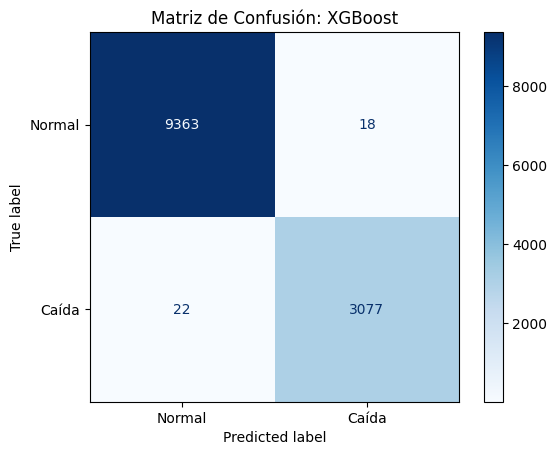

In [46]:
# Matriz de confusión XGboost

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Dibujar matriz de confusión correctamente
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=['Normal', 'Caída'],
    cmap=plt.cm.Blues,
    values_format='d'
)

plt.title('Matriz de Confusión: XGBoost')
plt.show()

### (XGBoost) Curva de precisión - Recall

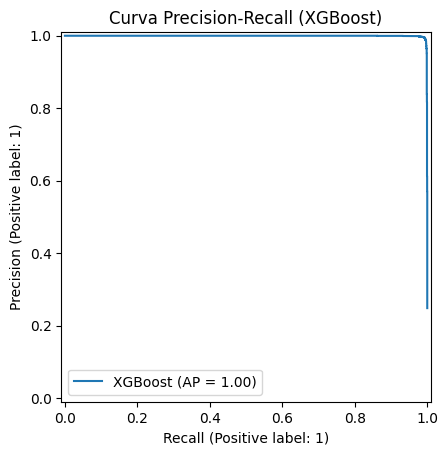

In [47]:
# Curva de precisión - Recall

import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

# Obtener probabilidades (clave para PR curve)
y_scores = xgb_model.predict_proba(X_test)[:, 1]

# Dibujar curva
disp = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_scores,
    name="XGBoost"
)

plt.title('Curva Precision-Recall (XGBoost)')
plt.show()

### (XGBoost) Probabilidades de caida(1) 

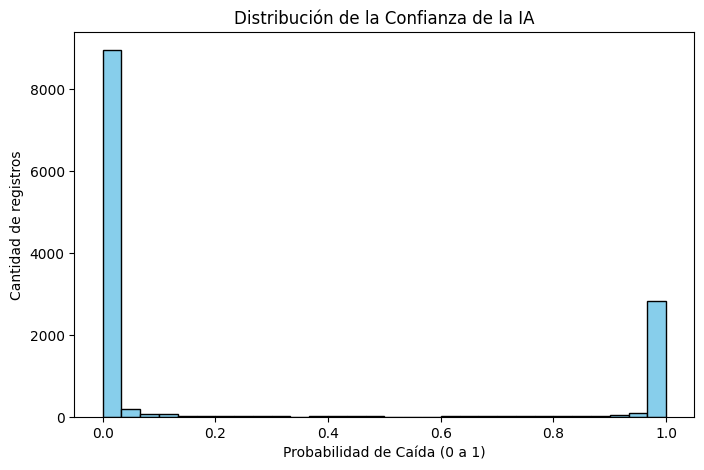

In [48]:
# Obtenemos las probabilidades de la clase 'Caída' para XGboost

probs_caida =xgb_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 5))
plt.hist(probs_caida, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de la Confianza de la IA')
plt.xlabel('Probabilidad de Caída (0 a 1)')
plt.ylabel('Cantidad de registros')
plt.show()

### (XGBoost) Intensidad de caidas (SMV)

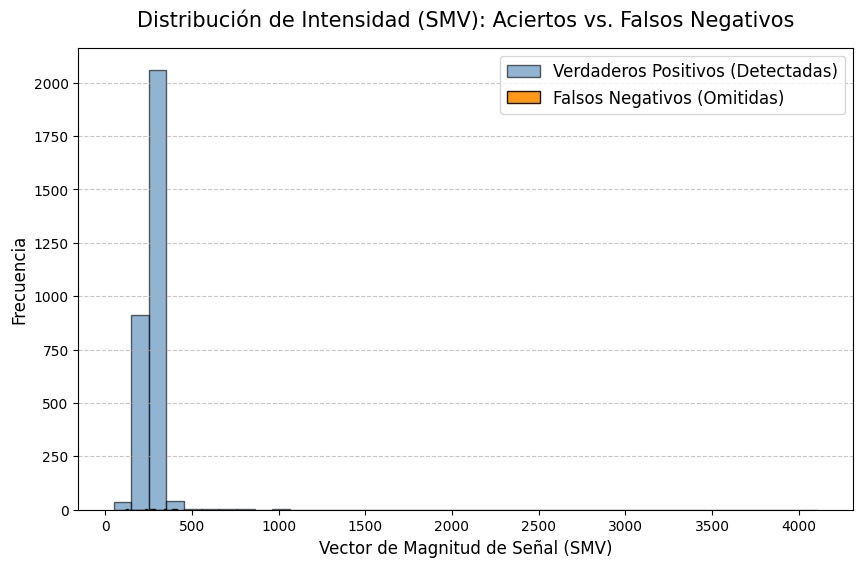

In [49]:
# Histograma de Intensidad de Caídas (SMV) para XGBoost

import matplotlib.pyplot as plt
import numpy as np

# Filtramos SOLO los casos que en la realidad eran CAÍDAS (y_test == 1)
caidas_reales = X_test[y_test == 1]
predicciones_caidas_reales = xgb_model.predict(caidas_reales)

# Separamos el SMV de las que detectamos bien y de las que fallamos
smv_aciertos = caidas_reales[predicciones_caidas_reales == 1]['smv'] # Verdaderos Positivos
smv_fallos = caidas_reales[predicciones_caidas_reales == 0]['smv']   # Falsos Negativos

# Dibujamos el gráfico
plt.figure(figsize=(10, 6))

# Histograma de aciertos (Azul)
plt.hist(smv_aciertos, bins=40, alpha=0.6, label='Verdaderos Positivos (Detectadas)', color='steelblue', edgecolor='black')

# Histograma de fallos (Naranja)
plt.hist(smv_fallos, bins=20, alpha=0.9, label='Falsos Negativos (Omitidas)', color='darkorange', edgecolor='black')

# Personalización formal
plt.title('Distribución de Intensidad (SMV): Aciertos vs. Falsos Negativos', fontsize=15, pad=15)
plt.xlabel('Vector de Magnitud de Señal (SMV)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## (XGBoost) Optimitzación del modelo

### (XGBoost) Buscar mejores hiperparametros para XGBoost con GridSearch (se mantiene comentada para no cargar en tiempo de computación)

In [50]:
# Buscar mejores hiperparámetros con GridSearch (XGBoost)
'''
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

# Calcular peso de clases (equivalente a class_weight en RF)
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Definimos el modelo base
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Definimos la rejilla de parámetros (adaptada a XGBoost)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Configuración del GridSearch
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='recall',   # clave: optimizamos detección de caídas
    cv=3,
    n_jobs=-1,
    verbose=1
)

print("=== EJECUTANDO GRID SEARCH XGBOOST ===")

# Entrenamiento
grid_search_xgb.fit(X_train, y_train)

# Mejor modelo
modelo_xgb_grid = grid_search_xgb.best_estimator_

print(f"\nMejores parámetros encontrados: {grid_search_xgb.best_params_}")

# Predicción
y_pred_xgb_grid = modelo_xgb_grid.predict(X_test)

# Evaluación
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_xgb_grid))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_xgb_grid))
'''

'\nfrom xgboost import XGBClassifier\nfrom sklearn.model_selection import GridSearchCV\nfrom sklearn.metrics import confusion_matrix, classification_report\n\n# Calcular peso de clases (equivalente a class_weight en RF)\nscale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])\n\n# Definimos el modelo base\nxgb_base = XGBClassifier(\n    random_state=42,\n    eval_metric=\'logloss\'\n)\n\n# Definimos la rejilla de parámetros (adaptada a XGBoost)\nparam_grid = {\n    \'n_estimators\': [100, 200],\n    \'max_depth\': [4, 6, 8],\n    \'learning_rate\': [0.05, 0.1],\n    \'subsample\': [0.8, 1.0]\n}\n\n# Configuración del GridSearch\ngrid_search_xgb = GridSearchCV(\n    estimator=xgb_base,\n    param_grid=param_grid,\n    scoring=\'recall\',   # clave: optimizamos detección de caídas\n    cv=3,\n    n_jobs=-1,\n    verbose=1\n)\n\nprint("=== EJECUTANDO GRID SEARCH XGBOOST ===")\n\n# Entrenamiento\ngrid_search_xgb.fit(X_train, y_train)\n\n# Mejor modelo\nmodelo_xgb_grid = 

In [51]:
### (XGBoost) Entrenamiento modelo optimizado XGBOOST

=== ENTRENANDO MODELO FINAL XGBOOST ===

MÉTRICAS MODELO FINAL XGBOOST
Accuracy (Exactitud global): 99.80%
Precision (Calidad alarmas): 99.74%
Recall (Caídas detectadas):  99.45%
F1-Score (Equilibrio):       99.60%
Average Precision (AP):      99.98%

 Artefacto guardado como: modelo_sisfall_xgboost.pkl


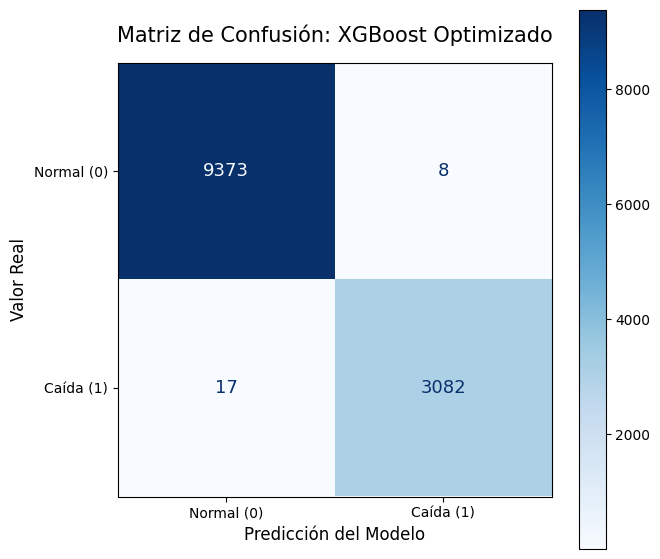

In [52]:
# ================================
# MODELO FINAL XGBOOST
# ================================

import joblib
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay
)

# Peso de clases (equivalente a class_weight)
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Mejores hiperparámetros obtenidos con GridSearch
mejor_modelo_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# Entrenamiento
print("=== ENTRENANDO MODELO FINAL XGBOOST ===")
mejor_modelo_xgb.fit(X_train, y_train)

# Predicciones
y_pred_xgb_final = mejor_modelo_xgb.predict(X_test)
y_probs_xgb_final = mejor_modelo_xgb.predict_proba(X_test)[:, 1]

# ================================
# MÉTRICAS
# ================================
print("\n" + "="*50)
print("MÉTRICAS MODELO FINAL XGBOOST")
print("="*50)

print(f"Accuracy (Exactitud global): {accuracy_score(y_test, y_pred_xgb_final)*100:.2f}%")
print(f"Precision (Calidad alarmas): {precision_score(y_test, y_pred_xgb_final)*100:.2f}%")
print(f"Recall (Caídas detectadas):  {recall_score(y_test, y_pred_xgb_final)*100:.2f}%")
print(f"F1-Score (Equilibrio):       {f1_score(y_test, y_pred_xgb_final)*100:.2f}%")
print(f"Average Precision (AP):      {average_precision_score(y_test, y_probs_xgb_final)*100:.2f}%")

print("="*50)

# ================================
# GUARDADO DEL MODELO
# ================================
nombre_archivo = 'modelo_sisfall_xgboost.pkl'
joblib.dump(mejor_modelo_xgb, nombre_archivo)

print(f"\n Artefacto guardado como: {nombre_archivo}")

# ================================
# MATRIZ DE CONFUSIÓN
# ================================
cm = confusion_matrix(y_test, y_pred_xgb_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal (0)', 'Caída (1)']
)

fig, ax = plt.subplots(figsize=(7, 7))

disp.plot(
    cmap='Blues',
    ax=ax,
    values_format='d',
    text_kw={'fontsize': 13}
)

plt.title('Matriz de Confusión: XGBoost Optimizado', fontsize=15, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)

plt.show()


### (XGBoost) Pruebas cualitativas con modelo optimizado

In [53]:
# Los mismos 4 casos que probamos en la prueba cualitativa con el modelo inicial, vamos a evaluarlos con el modelo optimizado

import pandas as pd

# Aseguramos el orden de las 10 columnas del modelo
columnas = X_train.columns.tolist()

# Datos registro los mismos registros de test que se han evaluado con el modelo inicial
# Formato: [acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z, smv, acc2_x, acc2_y, acc2_z]
datos_casos = [
    # CASO 1: ACIERTO CAÍDA
    [199.00, 50.00, -155.00, 51.00, 14.00, -4.00, 257.04, -378.00, 32.00, 976.00],
    # CASO 2: ACIERTO NORMAL
    [-17.00, -243.00, -114.00, 111.00, -573.00, -121.00, 269.17, 14.00, -1014.00, -432.00],
    # CASO 3: ANTES FALLO Falso Negativo 
    [-15.00, -267.00, -118.00, 121.00, -587.00, -82.00, 292.30, 35.00, -1025.00, -428.00],
    # CASO 4: ANTES FALLO Falso Positivo
    [-26.00, -250.00, -31.00, -134.00, -195.00, 29.00, 253.25, 6.00, -1026.00, -110.00]
]

titulos = [
    "CASO 1: CAÍDA DETECTADA (Anterior Acierto)",
    "CASO 2: ACTIVIDAD NORMAL (Anterior Acierto)",
    "CASO 3: CAÍDA NO DETECTADA (Anterior Falso Negativo)",
    "CASO 4: ALARMA FALSA (Anterior Falso Positivo)"
]

esperados = [1, 0, 1, 0]

print("=== EVALUACIÓN DEL MODELO OPTIMIZADO ===\n")

for i in range(len(datos_casos)):
    # Creamos el DataFrame con la estructura que el modelo conoce
    X_input = pd.DataFrame([datos_casos[i]], columns=columnas)
    
    # Predicción con el mejor modelo del GridSearch
    pred = mejor_modelo_xgb.predict(X_input)[0]
    prob = mejor_modelo_xgb.predict_proba(X_input)[0][pred] * 100
    
    print(f"--- {titulos[i]} ---")
    print(f"Output Esperado: {esperados[i]} | Output Real: {pred} ({prob:.2f}% confianza)")
    
    # Verificamos si la optimización ha corregido el error
    if pred == esperados[i]:
        status = "CORRECTO"
        if i >= 2: status += " (¡ERROR CORREGIDO!)"
    else:
        status = "INCORRECTO"
        
    print(f"Resultado: {status}\n")

=== EVALUACIÓN DEL MODELO OPTIMIZADO ===

--- CASO 1: CAÍDA DETECTADA (Anterior Acierto) ---
Output Esperado: 1 | Output Real: 1 (99.99% confianza)
Resultado: CORRECTO

--- CASO 2: ACTIVIDAD NORMAL (Anterior Acierto) ---
Output Esperado: 0 | Output Real: 1 (99.92% confianza)
Resultado: INCORRECTO

--- CASO 3: CAÍDA NO DETECTADA (Anterior Falso Negativo) ---
Output Esperado: 1 | Output Real: 1 (99.90% confianza)
Resultado: CORRECTO (¡ERROR CORREGIDO!)

--- CASO 4: ALARMA FALSA (Anterior Falso Positivo) ---
Output Esperado: 0 | Output Real: 1 (99.97% confianza)
Resultado: INCORRECTO



# Guardado del artefacto en el bucket S3

In [54]:
# Guardar el artefacto en el bucket S3 /output

import joblib
import boto3

# Configuración de nombres y rutas
bucket_name = 'sisfall-fall-detection'
model_filename = 'modelo_sisfall_optimizado.pkl'
s3_path = f'output/{model_filename}'

# Guardar el modelo en la máquina temporal
# Empaquetamos directamente el modelo XGBoost optimizado
joblib.dump(mejor_modelo_xgb, model_filename)
print(f"Modelo generado temporalmente: {model_filename}")

# Subida directa a Amazon S3
s3_client = boto3.client('s3')

try:
    print(f"Subiendo el artefacto a s3://{bucket_name}/{s3_path}...")
    s3_client.upload_file(model_filename, bucket_name, s3_path)
    print("El artefacto XGBoost se ha guardado correctamente en el bucket de S3.")
    
except Exception as e:
    print(f"Error al subir a S3: {e}")

Modelo generado temporalmente: modelo_sisfall_optimizado.pkl
Subiendo el artefacto a s3://sisfall-fall-detection/output/modelo_sisfall_optimizado.pkl...
¡Éxito! El artefacto XGBoost se ha guardado correctamente en tu bucket de S3.
